### Detailed Agentic RAG

In [ ]:
## Import necessary modules and libraries
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

import os
from dotenv import load_dotenv

load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")

### Langgraph Blogs

In [3]:
## Document loading
urls = [
    "https://langchain-ai.github.io/langgraph/tutorials/introduction/",
    "https://langchain-ai.github.io/langgraph/tutorials/workflows/",
    "https://langchain-ai.github.io/langgraph/how-tos/map-reduce/"
]

## Create the necessary chunks
docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1000, chunk_overlap=100
)

doc_splits = text_splitter.split_documents(docs_list)

## Create embeddings
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

## Add all these texts to vectordb
vectorstore = FAISS.from_documents(
    documents = doc_splits,
    embedding = embeddings
)

retriever = vectorstore.as_retriever()
retriever.invoke("What is langgraph?")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[Document(id='f8f1fe03-9f45-452e-8bc9-5ccb59c3d029', metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/introduction/', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...'),
 Document(id='1c70a51e-d3af-4817-955d-7cb40aed726d', metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/workflows/', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...'),
 Document(id='278c2538-cb46-45b7-a843-7a694d9a9e20', metadata={'source': 'https://langchain-ai.github.io/langgraph/how-tos/map-reduce/', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...')]

In [4]:
## Retriever To Retriever Tools
from langchain_classic.tools.retriever import create_retriever_tool

retriever_tool = create_retriever_tool(
    retriever,
    "retriever_vector_db_blog",
    "Search and run information about Langgraph"
)

## Integrate with LLM
retriever_tool

StructuredTool(name='retriever_vector_db_blog', description='Search and run information about Langgraph', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x00000269310B0EA0>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x00000269310B0E00>)

### Langchain Blogs - Seperate Vector Store


In [5]:
langchain_urls = [
    "https://python.langchain.com/docs/tutorials/",
    "https://python.langchain.com/docs/tutorials/chatbot/",
    "https://python.langchain.com/docs/tutorials/qa_chat_history/"
]

## Create the necessary chunks
docs = [WebBaseLoader(url).load() for url in langchain_urls]
docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1000, chunk_overlap=100
)

doc_splits = text_splitter.split_documents(docs_list)

## Create embeddings
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

## Add all these texts to vectordb
vectorstore = FAISS.from_documents(
    documents = doc_splits,
    embedding = embeddings
)

retrieverlangchain = vectorstore.as_retriever()
retrieverlangchain.invoke("What is langchain?")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[Document(id='3ecf50c1-0eec-4280-b4bc-22936ac415a5', metadata={'source': 'https://python.langchain.com/docs/tutorials/', 'title': 'LangChain overview - Docs by LangChain', 'description': 'LangChain provides create_agent: a minimal, highly configurable agent harness. Compose exactly the agent your use case needs from model, tools, prompt, and middleware.', 'language': 'en'}, page_content="LangChain overview - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what's next for agents. Get your tickets →Docs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangChain overviewOverviewDeep AgentsManaged Deep AgentsLangChainLangGraphOpenWikiIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogP

In [6]:
retriever_tool_langchain = create_retriever_tool(
    retrieverlangchain,
    "retriever_vector_langchain_blog",
    "Search and run information about Langchain"
)

## Integrate with LLM
retriever_tool_langchain

StructuredTool(name='retriever_vector_langchain_blog', description='Search and run information about Langchain', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x000002696B800860>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x000002696B800400>)

### LangGraph Workflow

In [7]:
from typing import Annotated, Sequence
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

tools = [retriever_tool,retriever_tool_langchain]

## 1. Create a state
class AgentState(TypedDict):
    ## The add_messages function defines how an update should be processed
    ## Default is to replace. add_messages says "append"
    messages: Annotated[Sequence[BaseMessage], add_messages]

from langchain_groq import ChatGroq

llm = ChatGroq(model = "openai/gpt-oss-120b")
llm.invoke("Hi")

AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "Hi". The assistant should respond politely. No special instructions. So just greet back.'}, response_metadata={'token_usage': {'completion_tokens': 40, 'prompt_tokens': 72, 'total_tokens': 112, 'completion_time': 0.082808197, 'completion_tokens_details': {'reasoning_tokens': 22}, 'prompt_time': 0.002833674, 'prompt_tokens_details': None, 'queue_time': 0.207896813, 'total_time': 0.085641871}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_90620edd96', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0b4a2-a127-7543-8cff-3423a0367aaf-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 40, 'total_tokens': 112, 'output_token_details': {'reasoning': 22}})

In [8]:
def agent(state):
    """
    Invokes the agent model to generate a response based on the current state. Given
    the question, it will decide to retrieve using the retriever tool, or simply end.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with the agent response appended to messages
    """

    print("---CALL AGENT---")
    messages = state["messages"]
    
    model = ChatGroq(model = "openai/gpt-oss-120b")
    model = model.bind_tools(tools)
    
    response = model.invoke(messages)
    
    ## We return a list, because this will get added to the existing list
    return {"messages": [response]}

In [10]:
from typing import Annotated, Literal, Sequence
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate

from pydantic import BaseModel, Field

## Edges
def grade_documents(state) -> Literal["generate", "rewrite"]:
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (messages): The current state

    Returns:
        str: A decision for whether the documents are relevant or not
    """

    print("---CHECK RELEVANCE---")

    ## Data model
    class grade(BaseModel):
        """Binary score for relevance check."""

        binary_score: str = Field(description = "Relevance score 'yes' or 'no'")

    ## LLM
    model = ChatGroq(model = "openai/gpt-oss-120b")

    ## LLM with tool and validation
    ## Return in the structured format
    llm_with_tool = model.with_structured_output(grade)

    ## Prompt
    prompt = PromptTemplate(
        template="""You are a grader assessing relevance of a retrieved document to a user question. \n 
        Here is the retrieved document: \n\n {context} \n\n
        Here is the user question: {question} \n
        If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.""",
        input_variables=["context", "question"],
    )

    ## Chain
    chain = prompt | llm_with_tool

    messages = state["messages"]
    last_message = messages[-1]

    question = messages[0].content
    docs = last_message.content

    scored_result = chain.invoke({"question": question, "context": docs})

    score = scored_result.binary_score

    if score == "yes":
        print("---DECISION: DOCS RELEVANT---")
        return "generate"

    else:
        print("---DECISION: DOCS NOT RELEVANT---")
        print(score)
        return "rewrite"

In [11]:
from langchain_classic import hub

def generate(state):
    """
    Generate answer

    Args:
        state (messages): The current state

    Returns:
         dict: The updated message
    """
    print("---GENERATE---")
    
    messages = state["messages"]
    
    question = messages[0].content
    last_message = messages[-1]

    docs = last_message.content

    ## Prompt
    prompt = hub.pull("rlm/rag-prompt")

    ## LLM
    llm = ChatGroq(model = "openai/gpt-oss-120b")

    ## Post-processing
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    ## Chain
    rag_chain = prompt | llm | StrOutputParser()

    ## Run
    response = rag_chain.invoke({"context": docs, "question": question})
    
    return {"messages": [response]}

In [12]:
def rewrite(state):
    """
    Transform the query to produce a better question.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with re-phrased question
    """

    print("---TRANSFORM QUERY---")
    messages = state["messages"]
    question = messages[0].content

    msg = [
        HumanMessage(
            content=f""" \n 
    Look at the input and try to reason about the underlying semantic intent / meaning. \n 
    Here is the initial question:
    \n ------- \n
    {question} 
    \n ------- \n
    Formulate an improved question: """,
        )
    ]

    ## Grader
    model = ChatGroq(model = "openai/gpt-oss-120b")
    response = model.invoke(msg)
    
    return {"messages": [response]}

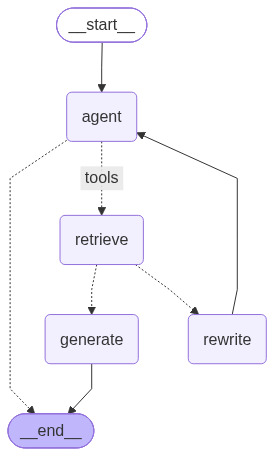

In [13]:
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode, tools_condition

## Define a new graph
workflow = StateGraph(AgentState)

## Define the nodes we will cycle between
workflow.add_node("agent", agent)  # agent
retrieve = ToolNode([retriever_tool,retriever_tool_langchain])

workflow.add_node("retrieve", retrieve)  # retrieval
workflow.add_node("rewrite", rewrite)  # Re-writing the question
workflow.add_node(
    "generate", generate
)  ## Generating a response after we know the documents are relevant

## Call agent node to decide to retrieve or not
workflow.add_edge(START, "agent")

## Decide whether to retrieve
workflow.add_conditional_edges(
    "agent",
    ## Assess agent decision
    tools_condition,
    {
        ## Translate the condition outputs to nodes in our graph
        "tools": "retrieve",
        END: END,
    },
)

## Edges taken after the `action` node is called.
workflow.add_conditional_edges(
    "retrieve",
    # Assess agent decision
    grade_documents,
)
workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "agent")

## Compile
graph = workflow.compile()

from IPython.display import Image, display
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [14]:
graph.invoke({"messages":"What is Langgraph?"})

---CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCS NOT RELEVANT---
no
---TRANSFORM QUERY---
---CALL AGENT---


{'messages': [HumanMessage(content='What is Langgraph?', additional_kwargs={}, response_metadata={}, id='1be1b32a-85b2-4b28-a4cc-653cb6e601e2'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to answer: "What is Langgraph?" Probably need to retrieve info from web. Use provided function retriever_vector_db_blog? The description: search about Langgraph. Use function.', 'tool_calls': [{'id': 'fc_1753840c-9e0d-443a-b823-22aa234f8e58', 'function': {'arguments': '{"query":"Langgraph"}', 'name': 'retriever_vector_db_blog'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 72, 'prompt_tokens': 172, 'total_tokens': 244, 'completion_time': 0.152648839, 'completion_tokens_details': {'reasoning_tokens': 40}, 'prompt_time': 0.05663295, 'prompt_tokens_details': None, 'queue_time': 0.242256058, 'total_time': 0.209281789}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_9241e9962b', 'service_tier': 'on_demand', 'finish_reason': 'to

In [15]:
graph.invoke({"messages":"What is Langchain?"})

---CALL AGENT---


{'messages': [HumanMessage(content='What is Langchain?', additional_kwargs={}, response_metadata={}, id='b52b002c-7cea-490c-a6dc-4c7d2caff17d'),
  AIMessage(content='**LangChain** is an open‑source framework that makes it easier to build applications powered by large language models (LLMs). It provides a set of modular, composable building blocks—**chains**, **agents**, **memory**, **prompts**, **data connectors**, and **evaluation tools**—that let developers focus on the *logic* of their application rather than on the low‑level plumbing required to interact with LLM APIs, retrieve external data, or maintain conversational state.\n\nBelow is a concise overview of what LangChain is, why it exists, its core concepts, and typical use‑cases.\n\n---\n\n## 1. Why LangChain Exists\n\n| Problem | Traditional Approach | LangChain Solution |\n|---------|----------------------|--------------------|\n| **Orchestrating multiple LLM calls** (e.g., prompt → LLM → post‑processing) | Write custom code 

In [16]:
graph.invoke({"messages":"What is Machine learning?"})

---CALL AGENT---


{'messages': [HumanMessage(content='What is Machine learning?', additional_kwargs={}, response_metadata={}, id='4f516e03-68f7-4d28-8d69-41c0988c89a9'),
  AIMessage(content='**Machine learning (ML)** is a sub‑field of artificial intelligence (AI) that focuses on building systems that can automatically improve their performance on a task through experience (i.e., by learning from data) rather than being explicitly programmed for every possible situation.\n\n### Core Idea\n- **Data\u202f+\u202fAlgorithm\u202f→\u202fModel**  \n  An ML algorithm processes a dataset, discovers patterns, and produces a **model**—a mathematical representation that can make predictions or decisions on new, unseen data.\n\n### Main Types of Machine Learning\n| Category | How it learns | Typical tasks | Example algorithms |\n|----------|--------------|---------------|--------------------|\n| **Supervised learning** | Learns from labeled examples (input‑output pairs) | Classification, regression | Linear regressio